In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors

import scanpy as sc

import os


import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols

# Some canonical markers for PBMC cell types that I found
canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [2]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])



entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)


## Load Fragments overlap CR-called peaks counts 
CR_frag_overlap_CRpeaks_file = os.path.join(entropy_dir, '_CRpipe_peak_frag_overlap_peak', 'overlap_peaks_counts.txt')
CR_frag_overlap_CRpeaks = pd.read_csv(CR_frag_overlap_CRpeaks_file, sep=' ', index_col=1, header=None)
CR_frag_overlap_CRpeaks.columns = ['frag_overlap_CRpeaks']
CR_frag_overlap_CRpeaks.index.name = None
CR_frag_overlap_CRpeaks['atac_bc'] = CR_frag_overlap_CRpeaks.index.map(lambda x: x.split('-1')[0])
CR_frag_overlap_CRpeaks.reset_index(inplace=True, drop=False)
CR_frag_overlap_CRpeaks.set_index('atac_bc', inplace=True)


## Load Fragments overlap CR-barcode-called peaks counts 
CRbcs_peak_frip_file = os.path.join(entropy_dir, 'CR_output', 'fragments_overlap_peaks', 'overlap_peaks_counts.txt')
CRbcs_peak_frip = pd.read_csv(CRbcs_peak_frip_file, sep=' ', index_col=1, header=None)
CRbcs_peak_frip.columns = ['frag_overlap_CRbcs_peaks']
CRbcs_peak_frip.index.name = None
CRbcs_peak_frip['atac_bc'] = CRbcs_peak_frip.index.map(lambda x: x.split('-1')[0])
CRbcs_peak_frip.reset_index(inplace=True, drop=False)
CRbcs_peak_frip.set_index('atac_bc', inplace=True)

In [3]:
if 'standard_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['entropy_peak_FRIP'], inplace=True)
if 'total_fragments' in entropy_df.columns:
    entropy_df.drop(columns=['total_fragments'], inplace=True)
if 'Nfrag_overlap_standard_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_standard_peak'], inplace=True)
if 'Nfrag_overlap_entropy_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_entropy_peak'], inplace=True)
    

entropy_df = entropy_df.merge(standard_peak_frip[['frag_overlap_peaks%', 'total_fragments', 'frag_overlap_peaks']].rename(
    columns={'frag_overlap_peaks%': 'standard_peak_FRIP', 'frag_overlap_peaks': 'Nfrag_overlap_standard_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%', 'frag_overlap_entropy_peaks']].rename(
    columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP', 'frag_overlap_entropy_peaks': 'Nfrag_overlap_entropy_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df['total_fragment_log1p'] = np.log1p(entropy_df['total_fragments'])



if 'frag_overlap_CRpeaks' in entropy_df.columns:
    entropy_df.drop(columns=['frag_overlap_CRpeaks'], inplace=True)
    
entropy_df = entropy_df.merge(CR_frag_overlap_CRpeaks[['frag_overlap_CRpeaks']],\
    left_on='atac_bc', right_index=True, how='left')

entropy_df['CRpeak_FRIP'] = entropy_df['frag_overlap_CRpeaks'] / entropy_df['total_fragments'] * 100


if 'frag_overlap_CRbcs_peaks' in entropy_df.columns:
    entropy_df.drop(columns=['frag_overlap_CRbcs_peaks'], inplace=True)
entropy_df = entropy_df.merge(CRbcs_peak_frip[['frag_overlap_CRbcs_peaks']],\
    left_on='atac_bc', right_index=True, how='left')    
entropy_df['CRbcs_peak_FRIP'] = entropy_df['frag_overlap_CRbcs_peaks'] / entropy_df['total_fragments'] * 100


In [4]:
entropy_df.head()

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,log10_Entropy,atac_bc,standard_peak_FRIP,total_fragments,Nfrag_overlap_standard_peak,entropy_peak_FRIP,Nfrag_overlap_entropy_peak,total_fragment_log1p,frag_overlap_CRpeaks,CRpeak_FRIP,frag_overlap_CRbcs_peaks,CRbcs_peak_FRIP
AAGCCATAGCTAATAG-1,0.005725,1.069145,11,0.343957,0.708959,0.999545,-2.242193,AAGCCATAGCTAATAG,3.930818,636,25.0,4.559748,29.0,6.456770,37.0,5.817610,29.0,4.559748
CACGGTAAGAATCACA-1,0.004039,1.910865,19,1.377521,0.252203,0.999694,-2.393755,CACGGTAAGAATCACA,3.393214,501,17.0,3.992016,20.0,6.218600,30.0,5.988024,20.0,3.992016
ACTGGCTTCTAACTGT-1,0.013996,2.526995,94,2.283363,0.101941,0.998739,-1.853984,ACTGGCTTCTAACTGT,5.901288,932,55.0,6.330472,59.0,6.838405,75.0,8.047210,59.0,6.330472
TCAGGCTTCTTTGGTG-1,0.004926,1.123864,10,0.376438,0.686302,0.999616,-2.307501,TCAGGCTTCTTTGGTG,4.285714,140,6.0,4.285714,6.0,4.948760,14.0,10.000000,7.0,5.000000
GGTTTACGTCACAGGG-1,0.007795,2.188419,43,1.624756,0.196960,0.999355,-2.108172,GGTTTACGTCACAGGG,3.285421,487,16.0,3.285421,16.0,6.190315,18.0,3.696099,16.0,3.285421


## Matching RNA and ATAC barcodes

In [5]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 19)

In [6]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_filtered_bc_df['atac_bc'])

In [7]:
entropy_df['identified_by_atac'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

In [8]:
entropy_df['identified_by_atac'].value_counts()

identified_by_atac
none            31102
both             1887
entropy_only      239
cr_only            59
Name: count, dtype: int64

In [9]:
CR_atacmodality_bc['atac_bc'].shape, 1887 + 59 
# This means 1959 - 1946 = 13 barcodes are unique to CR cell-calling do not have valid entropy values 

((1959,), 1946)

# Load fragments file that have all the barcodes in the experiments

In [10]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']
frag.head()

,chrom,start,end,support,atac_bc,frag_length
atac_BC,,,,,,
AGTAGGCGTCCATTAA-1,chr1,10067,10198,1,AGTAGGCGTCCATTAA,131
TGAGGCATCATCAGTT-1,chr1,10085,10333,3,TGAGGCATCATCAGTT,248
CCTAACTCATTTCGCG-1,chr1,10090,10309,1,CCTAACTCATTTCGCG,219
CATCACTCAGGTATTG-1,chr1,10091,10327,1,CATCACTCAGGTATTG,236
ACTCCTAAGTCTTAGT-1,chr1,10097,10308,1,ACTCCTAAGTCTTAGT,211


In [11]:
total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
total_frag_per_bc.columns = ['total_fragments']
total_frag_per_bc.head()

,total_fragments
atac_bc,
AAACAAGCAAACATGT,4
AAACAAGCAAACCAGC,1
AAACAAGCAAACCTAG,207
AAACAAGCAAACTAAC,1
AAACAAGCAAAGAAGC,987


In [12]:
if 'frag_overlap_CRpeaks' in total_frag_per_bc.columns:
    total_frag_per_bc.drop(columns=['frag_overlap_CRpeaks'], inplace=True)
    
total_frag_per_bc = total_frag_per_bc.merge(CR_frag_overlap_CRpeaks[['frag_overlap_CRpeaks']],\
    left_on='atac_bc', right_index=True, how='left')
total_frag_per_bc['frag_overlap_CRpeaks'] = total_frag_per_bc['frag_overlap_CRpeaks'].fillna(0)

total_frag_per_bc['CRpeak_FRIP'] = total_frag_per_bc['frag_overlap_CRpeaks'] / total_frag_per_bc['total_fragments'] * 100


In [13]:
total_frag_per_bc['atac_pass_CR'] = total_frag_per_bc.index.isin(CR_atacmodality_bc['atac_bc'])
total_frag_per_bc['atac_pass_entropy'] = total_frag_per_bc.index.isin(entropy_filtered_bc_df['atac_bc'])

total_frag_per_bc['identified_by_atac'] = total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

In [14]:
# Merge into entropy values and keep the invalid entropy value barcodes as well
if 'Entropy' in total_frag_per_bc.columns:
    total_frag_per_bc.drop(columns=['Entropy'], inplace=True)
total_frag_per_bc = total_frag_per_bc.merge(entropy_df[['Entropy']], left_index=True, right_index=True, how='left') 

In [15]:
total_frag_per_bc.head()

,total_fragments,frag_overlap_CRpeaks,CRpeak_FRIP,atac_pass_CR,atac_pass_entropy,identified_by_atac,Entropy
atac_bc,,,,,,,
AAACAAGCAAACATGT,4,1.0,25.000000,False,False,none,NaN
AAACAAGCAAACCAGC,1,1.0,100.000000,False,False,none,NaN
AAACAAGCAAACCTAG,207,23.0,11.111111,False,False,none,0.011025
AAACAAGCAAACTAAC,1,0.0,0.000000,False,False,none,NaN
AAACAAGCAAAGAAGC,987,72.0,7.294833,False,False,none,0.011332


In [16]:
total_frag_per_bc.groupby('identified_by_atac').size()

identified_by_atac
both              1887
cr_only             72
entropy_only       239
none            286811
dtype: int64

In [17]:
1887 / (1887 + 72)

0.9632465543644717

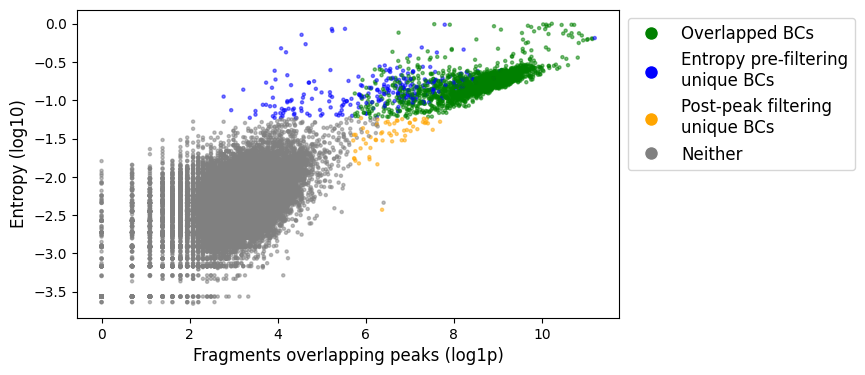

In [18]:
fig, ax = plt.subplots( figsize=(7, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['frag_overlap_CRpeaks']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping peaks (log1p)', fontsize=12)
ax.set_xlabel('Fragments overlapping peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)


ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Overlapped BCs',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy pre-filtering\nunique BCs',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='Post-peak filtering\nunique BCs',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Neither',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1.45, 1), loc='upper right', ncol=1, fontsize=12)

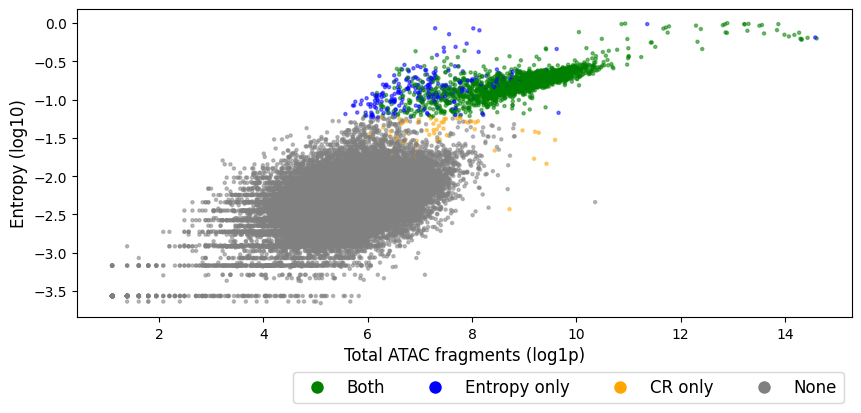

In [19]:
fig, ax = plt.subplots( figsize=(10, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

# cax_0 = ax.inset_axes([1.1, 0, 0.03, 1], transform=ax.transAxes)
# fig.colorbar(ax.collections, ax=ax, cax=cax_0, label='Fragments% overlapping called peaks')

plt.show()

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_3735457/2519565810.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax0.get_xticks()  ], fontsize=12)
/tmp/ipykernel_3735457/2519565810.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax1.get_xticks()  ], fontsize=12)


Text(3000, -1.5, '2126 BCs pass entropy pre-filtering')

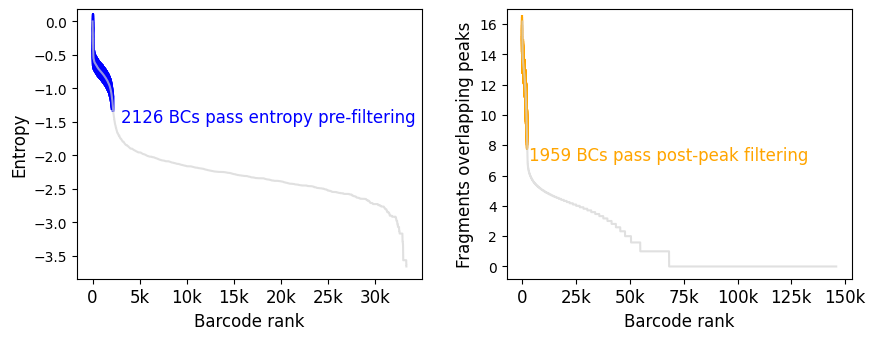

In [20]:


fig = plt.figure(figsize=(10, 3.5))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[:,11:])

ax1 = fig.add_subplot(gs[:,:9])


# ax0
sorted_frag_overlap_peaks = np.log2(total_frag_per_bc['frag_overlap_CRpeaks']).sort_values(ascending=False).to_frame()  # with barcodes as index
rank_list = np.arange( sorted_frag_overlap_peaks.shape[0] )
sorted_frag_overlap_peaks['rank_list'] = rank_list

ax0.plot( sorted_frag_overlap_peaks['rank_list'], sorted_frag_overlap_peaks['frag_overlap_CRpeaks'], '-', markersize=7, color='lightgray', alpha=0.7)
ax0.set_xlabel('Barcode rank', fontsize=12)
# ax0.set_ylabel('Fragments overlapping peaks (log)', fontsize=12)
ax0.set_ylabel('Fragments overlapping peaks', fontsize=12)
ax0.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax0.get_xticks()  ], fontsize=12)


barcodes = total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index
ax0.scatter(sorted_frag_overlap_peaks.loc[barcodes, 'rank_list'], 
            sorted_frag_overlap_peaks.loc[barcodes, 'frag_overlap_CRpeaks'], color='orange', label='Cell', s=130, alpha=1, marker="|")

ax0.text(3000, 7, f'{len(barcodes)} BCs pass post-peak filtering', fontsize=12, color='orange')
# ax0.legend(title='CR \npost-peak\ncell-calling', bbox_to_anchor=(1, 1), loc='upper left')

# ax1
sorted_log10entropy_series = np.log10(total_frag_per_bc['Entropy'].dropna().sort_values(ascending=False)).to_frame()  # with barcodes as index
rank_list = np.arange( len(sorted_log10entropy_series) )
sorted_log10entropy_series['rank_list'] = rank_list


ax1.plot( rank_list, sorted_log10entropy_series['Entropy'], '-', markersize=7, color='lightgray', alpha=0.7)
ax1.set_xlabel('Barcode rank', fontsize=12)
#ax1.set_ylabel('Entropy (log10)', fontsize=12)
ax1.set_ylabel('Entropy', fontsize=12)
# ax1.set_xlim((-1000, 30000))
ax1.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax1.get_xticks()  ], fontsize=12)

barcodes = total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index
ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
            sorted_log10entropy_series.loc[barcodes, 'Entropy'], color='blue', label='Cell', s=130, alpha=1, marker="|")
    
# ax1.legend(title='Entropy \npre-filtering', bbox_to_anchor=(1, 1), loc='upper left')
ax1.text(3000, -1.5, f'{len(barcodes)} BCs pass entropy pre-filtering', fontsize=12, color='blue')


----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [np.float64(70.09293350553217), np.float64(53.7556943958199), np.float64(57.92354036811493), np.float64(25.241626412258334)]
median 	 [np.float64(72.42582897033158), np.float64(69.77886977886978), np.float64(65.44656099369669), np.float64(1.694915254237288)]


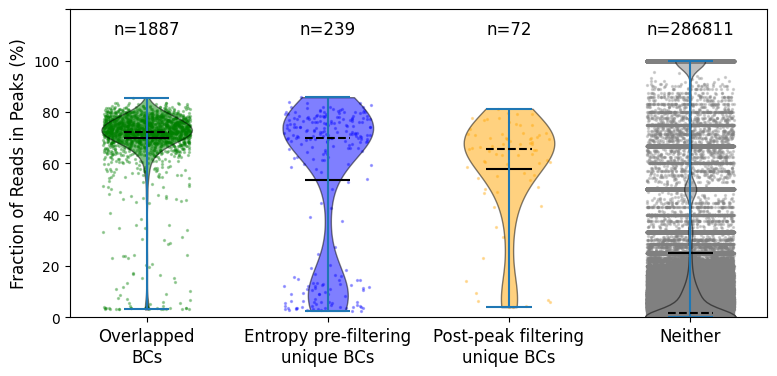

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy pre-filtering\nunique BCs', 'Post-peak filtering\nunique BCs', 'Neither'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

### How many barcoeds have invalid entropy values

In [22]:
total_frag_per_bc['invalid_entropy_value'] = ~total_frag_per_bc.index.isin(entropy_df.index)
total_frag_per_bc['invalid_entropy_value'].value_counts()

invalid_entropy_value
True     255722
False     33287
Name: count, dtype: int64

In [23]:
total_frag_per_bc.groupby(['invalid_entropy_value', 'identified_by_atac']).size().unstack()

identified_by_atac,both,cr_only,entropy_only,none
invalid_entropy_value,,,,
False,1887.0,59.0,239.0,31102.0
True,NaN,13.0,NaN,255709.0


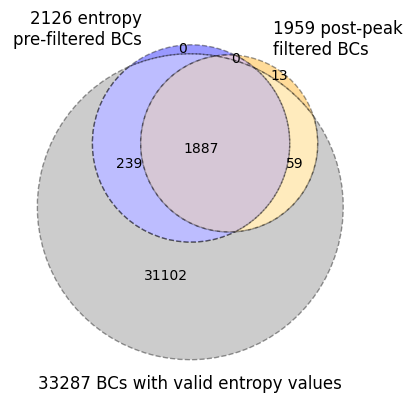

In [31]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based

venn_sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'CR post-peak filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()



# Filter fragments by each category BCs

In [ ]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['identified_by_atac'] == 'cr_only')
].index.values
CR_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [ ]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'cr_only'
].index.values
CR_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [ ]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'cr_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

CR_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [ ]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'entropy_only'
].index.values
Entropy_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [ ]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'both')
].index.values

Overlap_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [ ]:


fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR unique BCs with invalid entropy values', fontsize=14)

In [ ]:
fig, ax = plt.subplots(ncols=9, nrows=6, figsize=(25, 18)   )
ax = ax.flatten()

bcs = CR_unique_validEntropy_BC_frag['atac_bc'].unique()
bcs_ordered = entropy_df.loc[entropy_df['atac_bc'].isin(bcs) & ( entropy_df['CRpeak_FRIP'] > 20 ), ['Entropy']].sort_values(ascending=False, by='Entropy').index.values
I = min(len(ax), len(bcs_ordered))
for i in range(I):
    bc = bcs_ordered[i]
    bc_frag = CR_unique_validEntropy_BC_frag.loc[CR_unique_validEntropy_BC_frag['atac_bc'] == bc]
    ax[i].hist( bc_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
    ax[i].set_title(f'{bc} \n entropy: {np.log10(entropy_df.loc[bc, "Entropy"]):.2f} FRIP: {entropy_df.loc[bc, "CRpeak_FRIP"]:.2f}', fontsize=12)
fig.suptitle('CR Unique BC with valid Entropy Value & FRIP > 20\n', fontsize=16)
# fig.subplots_adjust(top=1)
fig.tight_layout()

fig, ax = plt.subplots(ncols=9, nrows=1, figsize=(25, 3))
ax = ax.flatten()

bcs = CR_unique_validEntropy_BC_frag['atac_bc'].unique()
bcs_ordered = entropy_df.loc[entropy_df['atac_bc'].isin(bcs) & ( entropy_df['CRpeak_FRIP'] <= 20 ), ['Entropy']].sort_values(ascending=False, by='Entropy').index.values
I = min(len(ax), len(bcs_ordered))
for i in range(I):
    bc = bcs_ordered[i]
    bc_frag = CR_unique_validEntropy_BC_frag.loc[CR_unique_validEntropy_BC_frag['atac_bc'] == bc]
    ax[i].hist( bc_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
    ax[i].set_title(f'{bc} \n entropy: {np.log10(entropy_df.loc[bc, "Entropy"]):.2f} FRIP: {entropy_df.loc[bc, "CRpeak_FRIP"]:.2f}', fontsize=12)
fig.suptitle('CR Unique BC with valid Entropy Value & FRIP <= 20', fontsize=16)
fig.tight_layout()

# Calculate correlation with chromosome level fragment frequency

In [ ]:
CRunique_chrom_counts = CR_unique_validEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Overlapped_chrom_counts = Overlap_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Entropyunique_chrom_counts = Entropy_unique_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)

for count in [CRunique_chrom_counts, Overlapped_chrom_counts, Entropyunique_chrom_counts]:
    # drop non-chromosome columns
    columns = [ col for col in count.columns if not col.startswith('chr') ]
    count.drop(columns=columns, inplace=True)

In [ ]:
CRunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=CRunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in CRunique_BC_corr.columns:
    CRunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( CRunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [ ]:
Entropyunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=Entropyunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in Entropyunique_BC_corr.columns:
    Entropyunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( Entropyunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [ ]:
CRunique_BC_corr.head()

In [ ]:
fig, ax = plt.subplots(ncols =2, figsize=(10, 4))

ax[0].hist( CRunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[0].set_xlabel('Correlation Coefficient', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('CR unique BCs')

ax[1].hist( Entropyunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[1].set_xlabel('Correlation Coefficient', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)
ax[1].set_title('Entropy unique BCs')
fig.suptitle('Chromosome Distribution Correlation with Overlapped BCs', fontsize=16)

fig.tight_layout()

mean_corr_CRunique = np.mean( CRunique_BC_corr.values.flatten() )
mean_corr_Entropyunique = np.mean( Entropyunique_BC_corr.values.flatten() )
median_corr_CRunique = np.median( CRunique_BC_corr.values.flatten() )
median_corr_Entropyunique = np.median( Entropyunique_BC_corr.values.flatten() )

print(f' ----- \t CRunique \t Entropyunique')
print(f'Mean \t {mean_corr_CRunique:.4f} \t {mean_corr_Entropyunique:.4f}')
print(f'Median \t {median_corr_CRunique:.4f} \t {median_corr_Entropyunique:.4f}')

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(10, 12), sharex=True)

chrom_counts_1 = Overlapped_chrom_counts.reindex( sorted(Overlapped_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts_1.iterrows():
    ax[0].plot( chrom_counts_1.columns, row / row.sum(),  )
ax[0].set_ylim(0, 0.2)
ax[0].set_title(f'{chrom_counts_1.shape[0]} Overedlapped BCs')
_ = ax[0].set_xticklabels(chrom_counts_1.columns, rotation=45)



chrom_counts_2 = Entropyunique_chrom_counts.reindex( sorted(Entropyunique_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

for idx, row in chrom_counts_2.iterrows():
    ax[1].plot( chrom_counts_2.columns, row / row.sum(),  )
ax[1].set_ylim(0, 0.2)
ax[1].set_title(f'{chrom_counts_2.shape[0]} Entropy Unique BCs')
_ = ax[1].set_xticklabels(chrom_counts_2.columns, rotation=45)


chrom_counts_3 = CRunique_chrom_counts.reindex( sorted(CRunique_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)
print(chrom_counts_3.shape)

# line plot per barcode 
for idx, row in chrom_counts_3.iterrows():
    ax[2].plot( chrom_counts_3.columns, row / row.sum(),  )
    
ax[2].set_ylim(0, 0.2)
ax[2].set_title(f'{chrom_counts_3.shape[0]} CR Unique BCs w valid entropy value')
_ = ax[2].set_xticklabels(chrom_counts_3.columns, rotation=45)

In [ ]:
CRunique_noEntropy_chrom_counts = CR_unique_noEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
CRunique_noEntropy_chrom_counts = CRunique_noEntropy_chrom_counts.drop( columns=[ col for col in CRunique_noEntropy_chrom_counts.columns if not col.startswith('chr') ] )

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4) )

chrom_counts = CRunique_noEntropy_chrom_counts.reindex( sorted(CRunique_noEntropy_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts.iterrows():
    ax[1].plot( chrom_counts.columns, row / row.sum(),  )
ax[1].set_ylim(0, 0.2)
ax[1].set_title(f'{chrom_counts.shape[0]} CR Unique BCs w/o valid entropy value')
_ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)

_ = ax[0].hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )

# Plot results

In [ ]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:5])
_ = ax0.hist(np.log10(entropy_df['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,8:])

sorted_log10entropy_list = np.log10(entropy_df['Entropy'].dropna().sort_values(ascending=False).values)
rank_list = np.arange( len(sorted_log10entropy_list) )
entropy_cutoff = entropy_df.loc[entropy_df['atac_pass_entropy'], 'Entropy'].min()
entropy_cutoff_log = np.log10(entropy_cutoff)


ax1.plot( rank_list, sorted_log10entropy_list, 'o', markersize=3)
ax1.set_xlabel('Barcode rank', fontsize=12)
# ax1.set_ylabel('log(Entropy)', fontsize=12)
ax1.axhline(entropy_cutoff_log, color='pink', linestyle='--', label='entropy threshold', lw=2)


In [ ]:


fig, ax = plt.subplots( figsize=(7, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log10(entropy_df['Nfrag_overlap_entropy_peak']), np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping entropy peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)



ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Overlapped BCs',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='BCs unique \nto Entropy',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='BCs unique \nto CR',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Neither',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=2, fontsize=12)

In [ ]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
gps_anno = ['BCs unique \nto Entropy', 'BCs unique \nto CR']
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
FRIP_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'CRpeak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))



vp1 = ax.violinplot( FRIP_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=5, norm=norm) # s controls point size
    return color_bar



for i, group_data in enumerate(FRIP_data):
    cb = add_jittered_points(ax, group_data, x_positions[i], 0,   color=entropy_values[i],color_range=color_range, jitter_width=0.15)

colorbar = fig.colorbar(cb, ax=ax, label='Entropy value (log10)')


for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.5)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps_anno, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_peak = [FRIP_data[i].median() for i in range(len(gps))]
mean_frip_peak = [FRIP_data[i].mean() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_peak[0], median_frip_peak[1]))
print("Mean \t {:.2f} \t {:.2f} \n".format(mean_frip_peak[0], mean_frip_peak[1]))

In [ ]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
gps_anno = ['BCs unique \nto Entropy', 'BCs unique \nto CR']
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
FRIP_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'CRpeak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))


vp1 = ax.violinplot( FRIP_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.7, s=5) # s controls point size



for i, group_data in enumerate(FRIP_data):
    add_jittered_points(ax, group_data, x_positions[i], jitter_width=0.2, color='orange' if gps[i]=='cr_only' else 'blue')



for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.4)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmedians'].set_linewidth(2)
vp1['cmeans'].set_linewidth(2)
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps_anno, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_standard_peak = [FRIP_data[i].median() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_standard_peak[0], median_frip_standard_peak[1]))

In [ ]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'Neither':'gray'}
gps = ['both', 'entropy_only', 'cr_only', 'none']
gps_anno = ['Overlapped BCs', 'BCs unique \nto Entropy', 'BCs unique \nto CR', 'Neither']
x_positions = range(len(gps))
widths=0.4
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(6, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_standard_peak'] for c in gps]
entropy_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_entropy_peak'] for c in gps]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=[x - 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.1, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i] - 0.2, color=colors_map['cr_only'])
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + 0.2 for x in x_positions][i], color=colors_map['entropy_only'])

ax.set_xticks(x_positions)
ax.set_xticklabels(gps_anno, rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Number of Fragments in Peaks', fontsize=12)


In [ ]:


fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:9])

sorted_frag_overlap_peaks = np.log2(entropy_df['Nfrag_overlap_entropy_peak']).sort_values(ascending=False).to_frame()  # with barcodes as index
rank_list = np.arange( sorted_frag_overlap_peaks.shape[0] )
sorted_frag_overlap_peaks['rank_list'] = rank_list

ax0.plot( sorted_frag_overlap_peaks['rank_list'], sorted_frag_overlap_peaks['Nfrag_overlap_entropy_peak'], '-', markersize=1, color='lightgray', alpha=0.4)
ax0.set_xlabel('Barcode rank', fontsize=12)
ax0.set_ylabel('Fragments overlapping peaks(log2)', fontsize=12)

barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax0.scatter(sorted_frag_overlap_peaks.loc[barcodes, 'rank_list'], 
            sorted_frag_overlap_peaks.loc[barcodes, 'Nfrag_overlap_entropy_peak'], color='orange', label='Pass_CR', s=130, alpha=1, marker="|")



ax1 = fig.add_subplot(gs[0:20,11:])

sorted_log10entropy_series = np.log10(entropy_df['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)


barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
            sorted_log10entropy_series.loc[barcodes, 'Entropy'], color='orange', label='Pass_CR', s=130, alpha=1, marker="|")
    
ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'CRbcs_peak_FRIP'].fillna(0) for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy\nunique BCs', 'CR unique\nBCs', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in CRbcs Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
#ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_xticklabels(['Overlapped\nBCs', 'BCs unique \nto Entropy', 'BCs unique \nto CR', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Entropy Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')



In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
frip_diff_values = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'CRbcs_peak_FRIP'] - \
    entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for \
        cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
frip_diff_values = [a.dropna() for a in frip_diff_values]
total_counts = [a.shape[0] for a in frip_diff_values]

mean_entropy_values = [np.mean(a) for a in frip_diff_values]
median_entropy_values = [np.median(a) for a in frip_diff_values]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_diff_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_diff_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('difference in FRIP (%)', fontsize=12)
ax.set_ylim(0, 7)
ax.set_yticks(range(0, 6, 1))
ax.set_title('FRIP Difference: CRbcs Peaks - Standard Peaks', fontsize=14)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)
    
print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] - \
    entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for \
        cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
entropy_vales = [a.dropna() for a in entropy_vales]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('difference in FRIP (%)', fontsize=12)
ax.set_ylim(0, 7)
ax.set_yticks(range(0, 6, 1))
ax.set_title('FRIP Difference: Entropy Peaks - Standard Peaks', fontsize=14)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)
    
print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'gray']
frip_diff_values = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'CRbcs_peak_FRIP'] - \
    entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] for \
        cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
frip_diff_values = [a.dropna() for a in frip_diff_values]
total_counts = [a.shape[0] for a in frip_diff_values]

mean_diff = [np.mean(a) for a in frip_diff_values]
median_diff = [np.median(a) for a in frip_diff_values]
min_diff = [np.min(a) for a in frip_diff_values]
max_diff = [np.max(a) for a in frip_diff_values]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_diff_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_diff_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('difference in FRIP (%)', fontsize=12)
ax.set_ylim(0, 3)
ax.set_yticks(range(0, 4, 1))
ax.set_title('FRIP Difference: CRbcs Peaks - Entropy Peaks', fontsize=14)


for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)
    
print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_diff}')
print(f'median \t {median_diff}')
print(f'min \t {min_diff}')
print(f'max \t {max_diff}')

# NEED to DELETE

In [ ]:
Entropy_unique_BC_frag['frag_length'] = Entropy_unique_BC_frag['end'] - Entropy_unique_BC_frag['start'] + 1

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist( Entropy_unique_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_title('Entropy Unique BCs')

In [ ]:
CR_unique_BC_frag['frag_length'] = CR_unique_BC_frag['end'] - CR_unique_BC_frag['start'] + 1

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR Unique BCs')

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_validEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR Unique BC with valid Entropy Value', fontsize=14)

In [ ]:
fig, ax = plt.subplots(ncols=9, nrows=7, figsize=(25, 16)   )
ax = ax.flatten()

bcs = Entropy_unique_BC_frag['atac_bc'].unique()
bcs_ordered = entropy_df.loc[entropy_df['atac_bc'].isin(bcs), ['Entropy']].sort_values(ascending=False, by='Entropy').index.values
for i in range(min(len(ax), len(bcs))):
    bc = bcs_ordered[i]
    bc_frag = Entropy_unique_BC_frag.loc[Entropy_unique_BC_frag['atac_bc'] == bc]
    ax[i].hist( bc_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
    ax[i].set_title(f'{bc} \n entropy: {np.log10(entropy_df.loc[bc, "Entropy"]):.2f} FRIP: {entropy_df.loc[bc, "CRpeak_FRIP"]:.2f}', fontsize=12)
fig.suptitle('Entropy Unique BCs', fontsize=16)
fig.subplots_adjust(top=0.6)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(ncols=9, nrows=8, figsize=(25, 18)   )
ax = ax.flatten()

bcs = Entropy_unique_BC_frag['atac_bc'].unique()
bcs_ordered = entropy_df.loc[entropy_df['atac_bc'].isin(bcs) & ( entropy_df['CRpeak_FRIP'] < 20 ), ['Entropy']].sort_values(ascending=False, by='Entropy').index.values
for i in range(min(len(ax), len(bcs_ordered))):
    bc = bcs_ordered[i]
    bc_frag = Entropy_unique_BC_frag.loc[Entropy_unique_BC_frag['atac_bc'] == bc]
    ax[i].hist( bc_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
    ax[i].set_title(f'{bc} \n entropy: {np.log10(entropy_df.loc[bc, "Entropy"]):.2f} FRIP: {entropy_df.loc[bc, "entropy_peak_FRIP"]:.2f}', fontsize=12)
fig.suptitle('Entropy Unique BCs (FRIP < 0.2)', fontsize=16)
fig.subplots_adjust(top=0.6)
fig.tight_layout()